__Classification__

__1) Чистка данных и EDA__

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('data\\train.csv', low_memory=False)
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

Почти все данные имеют тип 'object', числовые по смыслу колонки преобразуем в нужный тип.

In [4]:
num_col = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',  'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
            'Delay_from_due_date',	'Num_of_Delayed_Payment',	'Changed_Credit_Limit',	'Num_Credit_Inquiries',
            'Outstanding_Debt',	'Credit_Utilization_Ratio', 'Total_EMI_per_month',	'Amount_invested_monthly', 'Monthly_Balance']
df_0 = df.copy()
df_0[num_col] = df_0[num_col].apply(pd.to_numeric, errors='coerce')
df_0['Credit_History_Age'] = df_0['Credit_History_Age'].apply(lambda x: int(x.split()[0])*12 + int(x.split()[3]) 
                                                          if pd.isnull(x) == False else np.nan)

In [5]:
trans_df = df_0[num_col].isnull().sum() - df[num_col].isnull().sum() # Разность в количестве пропущенных значений до и после преобразования
trans_df = trans_df[trans_df > 0].sort_values(ascending=False)
trans_df

Annual_Income              6980
Age                        4939
Num_of_Loan                4785
Amount_invested_monthly    4305
Num_of_Delayed_Payment     2744
Changed_Credit_Limit       2091
Outstanding_Debt           1009
Monthly_Balance               9
dtype: int64

Поcле автоматического преобразования потералось много объектов, поэтому нужно скорректировать преобразование для данных столбцов.

In [6]:
df[trans_df.index].sample(5, random_state=121).value_counts() 

Annual_Income  Age  Num_of_Loan  Amount_invested_monthly  Num_of_Delayed_Payment  Changed_Credit_Limit  Outstanding_Debt  Monthly_Balance   
14951.22       38   8            48.06433449263111        21                      28.79                 3270.39           271.58806003014007    1
17963.45       44_  2            164.77616261536548       15                      6.75                  2052.02           235.1059397893888     1
27653.79       29   4_           133.4472917574785        9                       10.8                  13.24             337.82423681172315    1
34225.79       29   2            __10000__                15                      11.59                 592.68            281.7226162660637     1
Name: count, dtype: int64

В большинстве случаев доминирует ошибка, связанная с добавлением к числу символа '_' .

In [7]:
df_0 = df.copy()
df = df.apply(lambda x: x.astype('string').str.strip('_')) #Приводим все к string и избавляемся от '_'
df[num_col] = df[num_col].apply(lambda x: pd.to_numeric(x, errors='coerce')) # Приводим числовые признаки к числовому типу
df['Credit_History_Age'] = df['Credit_History_Age'].apply(lambda x: int(x.split()[0])*12 + int(x.split()[3]) 
                                                          if pd.isnull(x) == False else np.nan)
num_col.append('Credit_History_Age')
trans_df = df[num_col].isnull().sum() - df_0[num_col].isnull().sum() # Разность в количестве пропущенных значений до и после преобразования
trans_df = trans_df[trans_df > 0].sort_values(ascending=False)
trans_df #Ошибки были исправлены, значения типа '_' так же были заменены на NaN 

Changed_Credit_Limit    2091
dtype: int64

In [8]:
df.describe() # Рассмотрим числовые признаки. Видим, что в признаках есть выбросы, ошибки и пропуски

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.0,100000.0,84998.0,100000.0,100000.0,100000.0,100000.0,100000.0,92998.0,97909.0,98035.0,100000.0,100000.0,90970.000000,100000.0,95521.0,98800.0
mean,110.6497,176415.701298,4194.17085,17.09128,22.47443,72.46604,3.00996,21.06878,30.923342,10.389025,27.754251,1426.220376,32.285173,221.195405,1403.118217,637.412998,-30364372469635625254912.0
std,686.244717,1429618.051414,3183.686167,117.404834,129.05741,466.422621,62.647879,14.860104,226.031892,6.789496,193.177339,1155.129026,5.116875,99.741364,8306.04127,2043.319327,3181295008384102875267072.0
min,-500.0,7005.93,303.645417,-1.0,0.0,1.0,-100.0,-5.0,-3.0,-6.49,0.0,0.23,20.0,1.000000,0.0,0.0,-333333333333333314856026112.0
25%,24.0,19457.5,1625.568229,3.0,4.0,8.0,1.0,10.0,9.0,5.32,3.0,566.0725,28.052567,144.000000,30.30666,74.534002,270.092209
50%,33.0,37578.61,3093.745,6.0,5.0,13.0,3.0,18.0,14.0,9.4,6.0,1166.155,32.305784,219.000000,69.249473,135.925682,336.71919
75%,42.0,72790.92,5957.448333,7.0,7.0,20.0,5.0,28.0,18.0,14.87,9.0,1945.9625,36.496663,302.000000,161.224249,265.731733,470.220186
max,8698.0,24198062.0,15204.633333,1798.0,1499.0,5797.0,1496.0,67.0,4397.0,36.97,2597.0,4998.07,50.0,404.000000,82331.0,10000.0,1602.040519


Изучим процент выбросов и ошибок в каждом числовом столбце. Довольно большой процент получился для признаков связанных с деньгами и доходом - это не будем считать выбросами.

Text(0.5, 1.0, 'Процент выбросов в признаках')

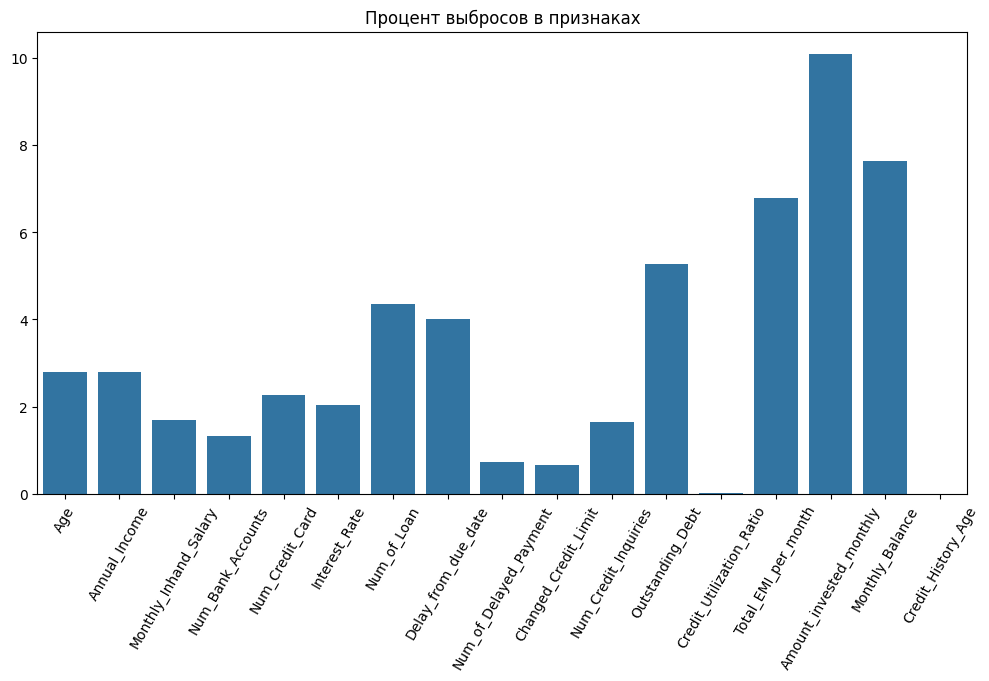

In [9]:
df_iqr = {}
for col in num_col:
    Q25 = df[col].quantile(0.25)
    Q75 = df[col].quantile(0.75)
    IQR = Q75 - Q25
    sm = df[(df[col] < Q25 - 1.5 * IQR) | (df[col]  > Q75 + 1.5 * IQR)].shape[0]
    df_iqr[col] = sm/len(df[col])*100
plt.figure(figsize=(12,6))
sns.barplot(df_iqr)
plt.xticks(rotation = 60)
plt.title('Процент выбросов в признаках')

Совершим масшатбирование признаков. Определим по смыслу нижние и верхние значения для признаков.

In [10]:
df['Age'] = df['Age'].where(
    (df['Age'] >= 18) & (df['Age'] <= 100),
    np.nan) #Очищаем слишком большие или отрицательные значения

df[['Num_Bank_Accounts','Num_Credit_Card', 'Num_of_Loan']] = df[['Num_Bank_Accounts',	'Num_Credit_Card', 'Num_of_Loan']].where(
    (df[['Num_Bank_Accounts','Num_Credit_Card', 'Num_of_Loan']] >= 0) & (df[['Num_Bank_Accounts','Num_Credit_Card', 'Num_of_Loan']] <= 20),
    np.nan)

df[['Interest_Rate', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',	'Num_Credit_Inquiries']] = df[['Interest_Rate', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',	'Num_Credit_Inquiries']].where(
    (df[['Interest_Rate', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',	'Num_Credit_Inquiries']] >= 0) & (df[['Interest_Rate', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',	'Num_Credit_Inquiries']] <= 100),
    np.nan)

df['Monthly_Balance'] = df['Monthly_Balance'].where(
    df['Monthly_Balance'] >= 0,
    np.nan)

df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan) #Плохое значение



Получили довольно хорошее распределение, для большой выборки выбросов немного.

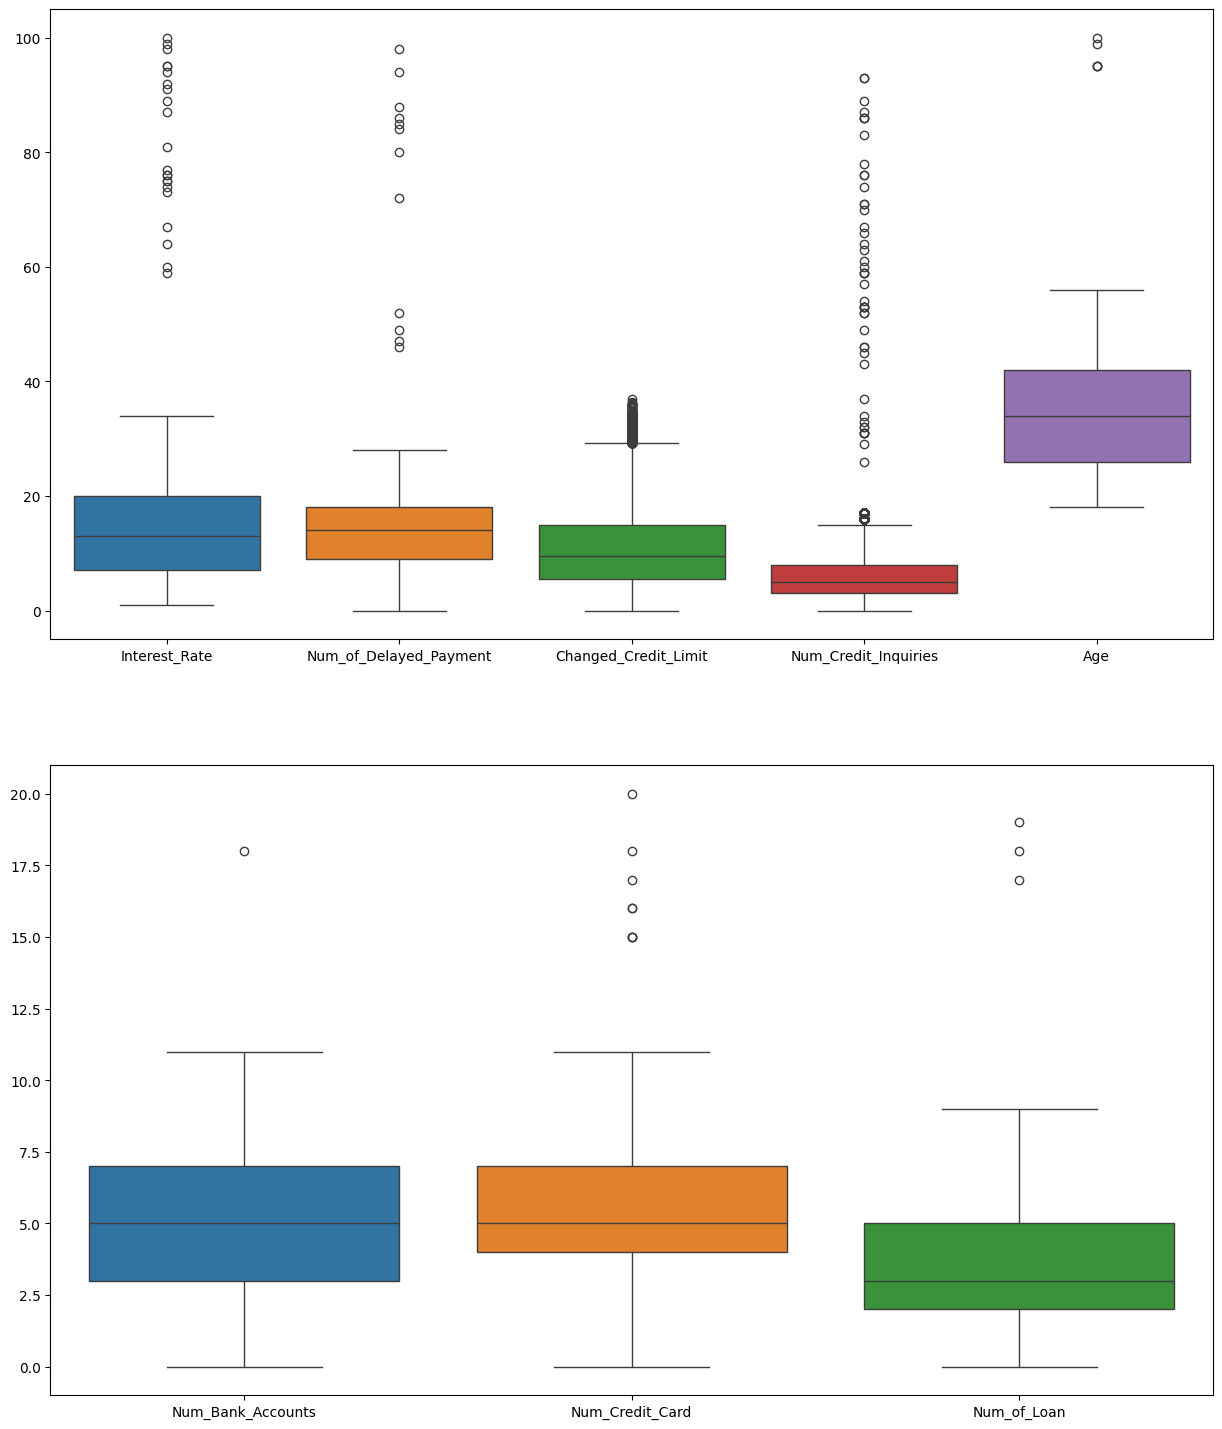

In [11]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize = (15,18))
sns.boxplot(data = df[['Interest_Rate', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',	'Num_Credit_Inquiries', 'Age']],ax=ax[0])
ax[1] = sns.boxplot(data = df[['Num_Bank_Accounts','Num_Credit_Card', 'Num_of_Loan']], ax=ax[1])

Text(0.5, 1.0, 'Корреляция между признаками')

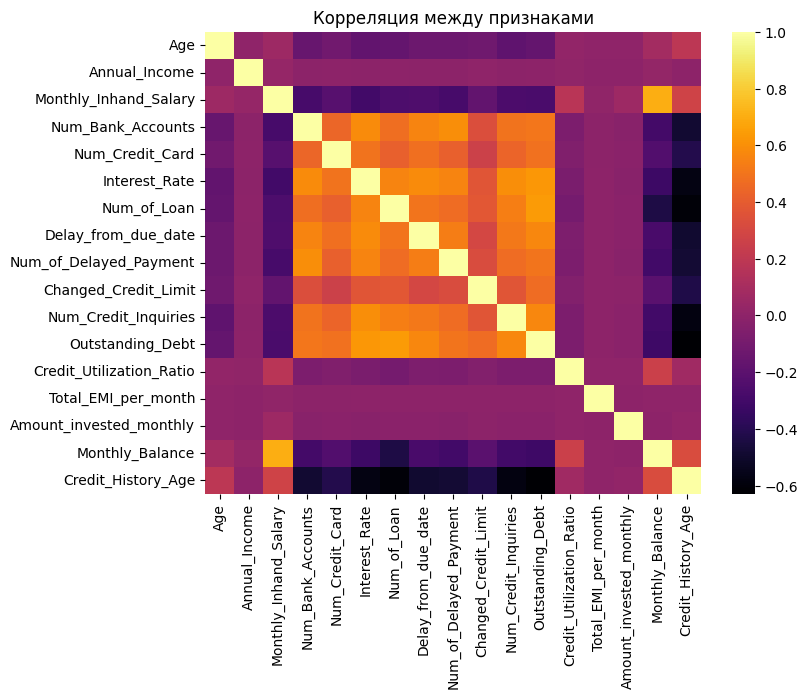

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(data = df[num_col].corr(), cmap='inferno') #Есть довольно сильнокоррелирующие признаки, будем использовать регуляризацию
plt.title('Корреляция между признаками')

Итог: данные очищены от ошибочных и нереалистичных значений и готовы к построению пайплайна.

__2) Построение пайплайна__

In [13]:
from sklearn.model_selection import GroupShuffleSplit
X = df.drop('Credit_Score', axis=1) # Отделяем признаки и целевые значения
y = df['Credit_Score']
labels = {"Poor": 0, "Standard": 1, "Good": 2} # Сделаем сразу Label Encoding целевых категорий
y = y.map(labels)

In [14]:
gsp = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_i, test_i = next(gsp.split(X, y, groups=df['Customer_ID'])) #Сделаем разбиение на train и test по группам customer id, избежав утечки данных
X_train, X_test = X.iloc[train_i], X.iloc[test_i]
y_train, y_test = y.iloc[train_i], y.iloc[test_i]

Теперь проведем Label и One Hot Encoding. Также обработаем пропуски, заполнив их для числовых признаков медианой, а для категорий наиболее часто встречающимся значением. 

In [15]:
X_train['Type_of_Loan'].value_counts() # Очень много уникальных значений. По сути бесполезный признак, позже удалим

Type_of_Loan
Not Specified                                                                         1112
Personal Loan                                                                         1048
Credit-Builder Loan                                                                    968
Student Loan                                                                           960
Debt Consolidation Loan                                                                944
                                                                                      ... 
Home Equity Loan, Not Specified, Student Loan, and Mortgage Loan                         8
Payday Loan, Credit-Builder Loan, Mortgage Loan, Home Equity Loan, and Payday Loan       8
Home Equity Loan, Payday Loan, Not Specified, and Personal Loan                          8
Home Equity Loan, Auto Loan, Auto Loan, and Auto Loan                                    8
Personal Loan, Auto Loan, Mortgage Loan, Student Loan, and Student Loan      

In [16]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
X_train = X_train.astype('object').where(pd.notna(X_train), np.nan) # Преобразуем в типы, с которыми умеет обращаться sklearn
X_test = X_test.astype('object').where(pd.notna(X_test), np.nan)


transfomer = ColumnTransformer([ 
    ('one_hot', 
    Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), 
    ['Occupation', 'Payment_of_Min_Amount', 'Payment_Behaviour']
    ),

    ('ordinal',
    Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ordinal', OrdinalEncoder(categories=[['', 'Bad', 'Standard', 'Good']], handle_unknown='use_encoded_value', unknown_value=-1))]), 
    ['Credit_Mix'] # Добавим новую категорию '', по смыслу это неизвестное значения. Таких значений очень много в сете - порядка 20 процентов
    ),


    ('num',
    SimpleImputer(strategy='median'),
    num_col
    ),

    ('drop', 'drop', ['Name', 'ID', 'SSN', 'Customer_ID', 'Type_of_Loan', 'Month']) # Удалим не несущие информацию столбцы
    ],
    remainder='drop'
)
transfomer

ColumnTransformer(transformers=[('one_hot',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('one_hot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Occupation', 'Payment_of_Min_Amount',
                                  'Payment_Behaviour']),
                                ('ordinal',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categorie...
                                  'Num_Credit_Card', 'Interest_Rate',
                                  'Num_of_Loan', 'Delay_from_due_date',
                                  'Num_of_Delayed_Payment',
                                  'Changed_Credit_Limit',
                                  'Num_Credit_Inquiries', 'Outstanding_Debt',
                                  'Credit_Utilization_Ratio',
                                  'Total_EMI_per_month',
                                  'Amount_invested_monthly', 'Monthly_Balance',
                                  'Credit_History_Age']),
                                ('drop', 'drop',
                                 ['Name', 'ID', 'SSN', 'Customer_ID',
                                  'Type_of_Loan', 'Month'])])

Преобразуем тестовые данные. Заметим, что присутствует небольшой дисбаланс классов (классы 'Good' и 'Poor' в меньшинстве).

Text(0.5, 1.0, 'Количество экземпляров каждого класса')

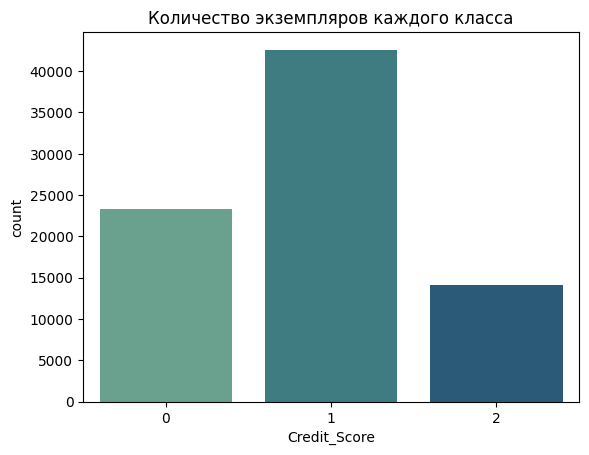

In [17]:
sns.countplot(x = y_train, palette='crest')
plt.title('Количество экземпляров каждого класса')

Построим окончательный пайплайн для baseline. Посмотрим на результат применения логистической регрессии и случайного леса.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
model_log = LogisticRegression(class_weight='balanced')
baseline_log = Pipeline([ #Построим базовую модель на логистической регрессии
    ('transformer', transfomer),
    ('scaler', StandardScaler()),
    ('logr', model_log)
])
baseline_log.fit(X_train, y_train)
y_pred = baseline_log.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.70      0.65      5726
           1       0.78      0.50      0.61     10580
           2       0.45      0.83      0.58      3694

    accuracy                           0.62     20000
   macro avg       0.62      0.67      0.61     20000
weighted avg       0.67      0.62      0.62     20000



In [19]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(class_weight='balanced')
baseline_rf = Pipeline([ #Построим базовую модель на случайном лесе (нелинейная модель)
    ('transformer', transfomer),
    ('rf', model_rf)
])
baseline_rf.fit(X_train, y_train)
y_pred = baseline_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.67      0.69      5726
           1       0.71      0.76      0.73     10580
           2       0.59      0.54      0.56      3694

    accuracy                           0.69     20000
   macro avg       0.67      0.66      0.66     20000
weighted avg       0.69      0.69      0.69     20000



В общем видно, что связи между признаками и целевой переменной довольно сложные, поэтому попробуем построить оптимальный XGBClassifier 

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.utils.class_weight import compute_sample_weight

weights = compute_sample_weight(class_weight="balanced", y=y_train) # Зададим каждому объекту сбалансированные веса в условиях дисбаланса классов

model_xgb = XGBClassifier(booster = 'gbtree', n_jobs = -1)
xgb = Pipeline([ 
    ('transformer', transfomer),
    ('xgb', model_xgb)
])

params = {
    'xgb__n_estimators': randint(50,800), # Количество деревьев
    'xgb__max_depth': randint(3, 8), # Максимальная глубина деревьев
    'xgb__learning_rate': uniform(0.01, 0.3) # Скорость обучения градиентного бустинга
}
rcv = RandomizedSearchCV( # Используем случайный подбор гиперпараметров для наиболее эффективного поиска
    xgb,
    params,
    scoring='roc_auc_ovr', # Будем подбирать, максимизируя roc_auc.
    n_jobs = -1,
    cv = 4,
    verbose = 1,
    n_iter=50
)

In [21]:
rcv.fit(X_train, y_train, xgb__sample_weight = weights)

Fitting 4 folds for each of 50 candidates, totalling 200 fits


RandomizedSearchCV(cv=4,
                   estimator=Pipeline(steps=[('transformer',
                                              ColumnTransformer(transformers=[('one_hot',
                                                                               Pipeline(steps=[('imp',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('one_hot',
                                                                                                OneHotEncoder(handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['Occupation',
                                                                                'Payment_of_Min_Amount',
                                                                                'Payment_Behaviour']),
                                                                              ('ordinal',
                                                                               Pipeline(steps=[('imp',
                                                                                                SimpleImput...
                   param_distributions={'xgb__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000201B341CBF0>,
                                        'xgb__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000201AE536990>,
                                        'xgb__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000201B3429550>},
                   scoring='roc_auc_ovr', verbose=1)

In [22]:
rcv.best_params_

{'xgb__learning_rate': np.float64(0.03969597328287146),
 'xgb__max_depth': 6,
 'xgb__n_estimators': 133}

__3) Оценка модели и выводы__

Исходя из проблемы, которую мы решаем, наиболее выгодно было бы стараться не давать кредит человеку с рейтингом "Poor". В то же время нежелательно отказываться от выдачи кредита подходящему человеку

In [23]:
y_pred = rcv.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.79      0.71      5726
           1       0.85      0.57      0.68     10580
           2       0.53      0.84      0.65      3694

    accuracy                           0.68     20000
   macro avg       0.67      0.73      0.68     20000
weighted avg       0.73      0.68      0.68     20000



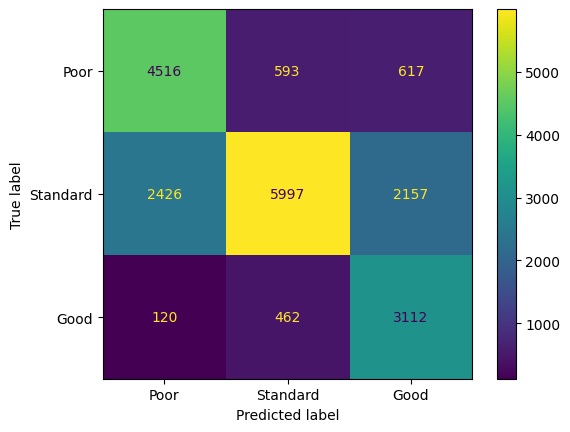

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
classes = ['Poor', 'Standard', 'Good']
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot()

Этот отчет показывает довольно средние показатели модели. Модель показывает macro F1 = 0.68. С одной стороны модель находит почти все элементы более редких классов, но с другой часто ошибается. Для бизнеса все-таки такая информация не очень полезна.

Наиболее важными метриками выступят ROC AUC и Average Precision, которые покажут, как ведет себя модель при разных порогах.

Text(0.5, 1.0, 'PR Curve')

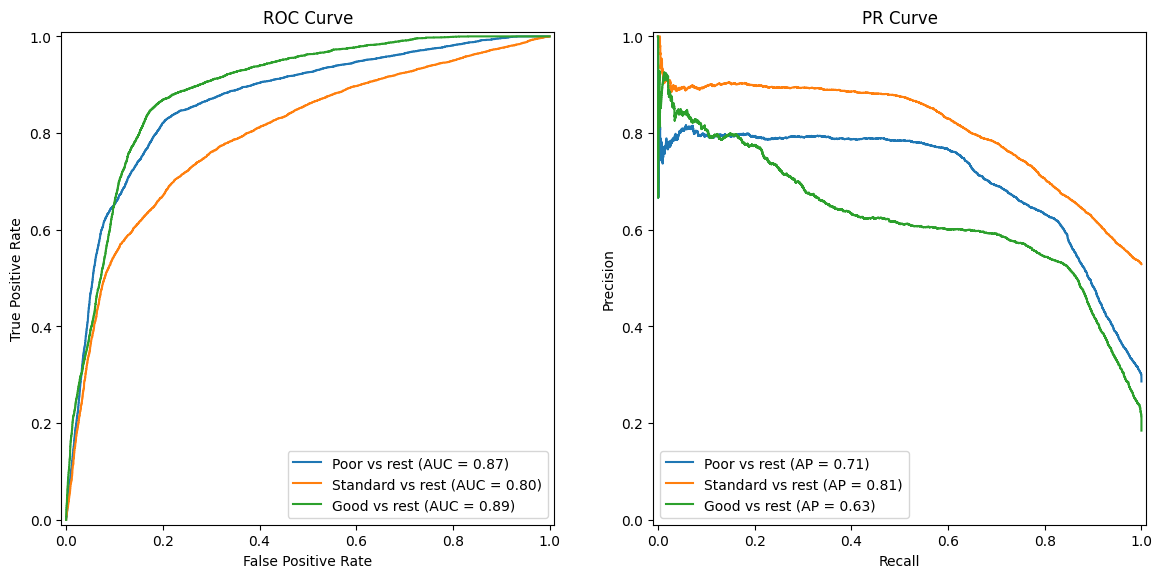

In [25]:
from sklearn.metrics import roc_curve, RocCurveDisplay, auc, precision_recall_curve, PrecisionRecallDisplay, average_precision_score
from sklearn.preprocessing import LabelBinarizer
bin = LabelBinarizer() # Бинаризируем тест для использования One vs Rest
y_test_bin = bin.fit_transform(y_test)
y_proba = rcv.predict_proba(X_test)
fig, ax = plt.subplots(figsize=(14,8), ncols=2, nrows=1)
for i in range(3):
    fpr, tpr, treshold = roc_curve(y_test_bin[:,i], y_proba[:, i])
    auc_score = auc(fpr, tpr)
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score).plot(ax=ax[0], name=f'{classes[i]} vs rest')
for i in range(3):
    precision, recall, treshold = precision_recall_curve(y_test_bin[:,i], y_proba[:, i])
    average_precision = average_precision_score(y_test_bin[:,i], y_proba[:, i])
    PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=average_precision).plot(ax=ax[1], name=f'{classes[i]} vs rest')
ax[0].set_title('ROC Curve')
ax[1].set_title('PR Curve')


Получился достаточно высокий ROC auc, что особенно важно для классов 'Poor' и 'Good'. Это значит что модель может хорошо упорядочить классы между других. Но более объективной метрикой будем считать average precision, так как скорее всего ROC auc не очень объективный из-за дисбаланса классов.

Average precision тоже довольно неплохой, особенно результат для класс 'Poor'. На PR кривой видно, что можно выбрать порог так, чтобы быть достаточно уверенным в том, что модель определит людей, которым кредит давать нежелательно, и в то же время найдет много таких людей.

__Как потенциально можно улучшить модель?__

Text(0.5, 1.0, 'Самые важные признаки')

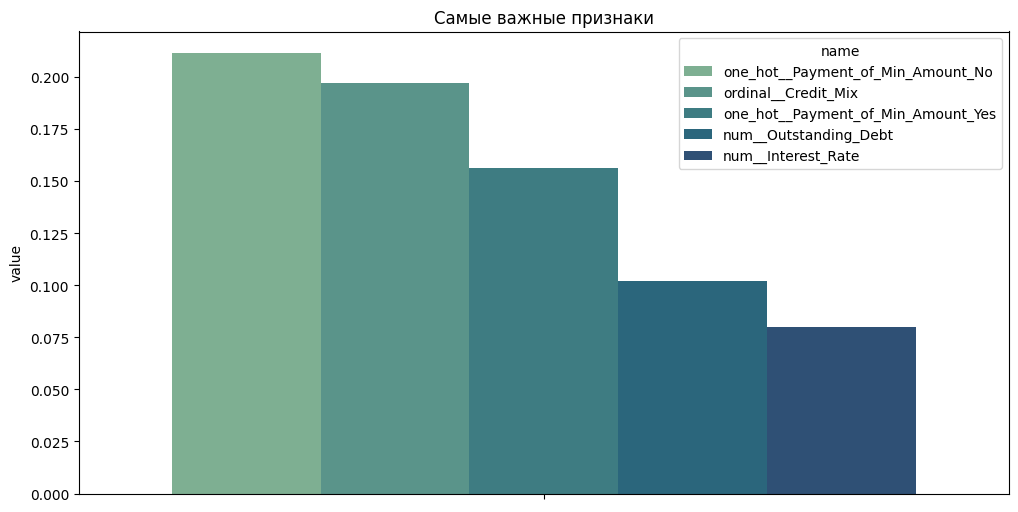

In [26]:
fi = rcv.best_estimator_['xgb'].feature_importances_
fi_names = rcv.best_estimator_['transformer'].get_feature_names_out()
fi_df = pd.DataFrame({'value': fi, 'name': fi_names})
fi_df = fi_df.sort_values(by='value', ascending=False).iloc[0:5]
plt.figure(figsize=(12,6))
sns.barplot(data = fi_df, y = 'value', hue = 'name', palette='crest')
plt.xticks(rotation = 30)
plt.title('Самые важные признаки')

In [27]:
print(classification_report(y_train, rcv.predict(X_train))) # Результаты модели на тренировочной выборке

              precision    recall  f1-score   support

           0       0.67      0.78      0.72     23272
           1       0.87      0.58      0.70     42594
           2       0.51      0.86      0.64     14134

    accuracy                           0.69     80000
   macro avg       0.68      0.74      0.68     80000
weighted avg       0.74      0.69      0.69     80000



Модель не очень хорошо показывает себя на тренировочной выборке. Я думаю, что это не совсем признак того, что наша модель недообучилась и слишком 'простая'. Скорее всего дело в признаках.
Много признаков почти не влияют на обучение модели, не несут полезной информации. Возможно, нужно провести дополнительное редактирование признаков: добавить новые и удалить ненужные.